In [2]:
import pandas as pd

In [3]:
df=pd.read_csv(r"C:\MACHINE LEARNING PROJECTS\MULTI LOGESTICS REGRESSION\credit card fraude dection\fraud_data.csv")
df

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,online,laptop,india,flipkart,credit,62,25,0
1,960,5,online,mobile,india,amazon,debit,23,45,0
2,38258,19,offline,laptop,foreign,walmart,debit,52,13,0
3,44832,1,online,laptop,india,amazon,debit,63,44,0
4,11384,23,offline,mobile,foreign,amazon,debit,31,43,0
...,...,...,...,...,...,...,...,...,...,...
995,15828,13,offline,mobile,foreign,amazon,debit,64,25,0
996,23375,3,online,laptop,india,flipkart,credit,28,24,0
997,6838,12,offline,laptop,foreign,walmart,debit,36,10,0
998,16013,7,online,mobile,foreign,local_shop,credit,52,22,0


In [4]:
df.isnull().sum()

amount                   0
time                     0
transaction_type         0
device                   0
location                 0
merchant                 0
card_type                0
customer_age             0
num_prev_transactions    0
is_fraud                 0
dtype: int64

In [5]:
df.head()

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,online,laptop,india,flipkart,credit,62,25,0
1,960,5,online,mobile,india,amazon,debit,23,45,0
2,38258,19,offline,laptop,foreign,walmart,debit,52,13,0
3,44832,1,online,laptop,india,amazon,debit,63,44,0
4,11384,23,offline,mobile,foreign,amazon,debit,31,43,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   amount                 1000 non-null   int64 
 1   time                   1000 non-null   int64 
 2   transaction_type       1000 non-null   object
 3   device                 1000 non-null   object
 4   location               1000 non-null   object
 5   merchant               1000 non-null   object
 6   card_type              1000 non-null   object
 7   customer_age           1000 non-null   int64 
 8   num_prev_transactions  1000 non-null   int64 
 9   is_fraud               1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [7]:
df.describe()

,amount,time,customer_age,num_prev_transactions,is_fraud
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,24592.139000,11.320000,43.389000,24.139000,0.13600
std,14632.696566,6.943905,14.969227,14.096041,0.34296
min,109.000000,0.000000,18.000000,0.000000,0.00000
25%,11480.000000,5.000000,30.750000,13.000000,0.00000
50%,23965.000000,11.000000,43.000000,23.000000,0.00000
75%,37953.750000,17.000000,57.000000,36.000000,0.00000
max,49950.000000,23.000000,69.000000,49.000000,1.00000


In [8]:
df.columns

Index(['amount', 'time', 'transaction_type', 'device', 'location', 'merchant',
       'card_type', 'customer_age', 'num_prev_transactions', 'is_fraud'],
      dtype='object')

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

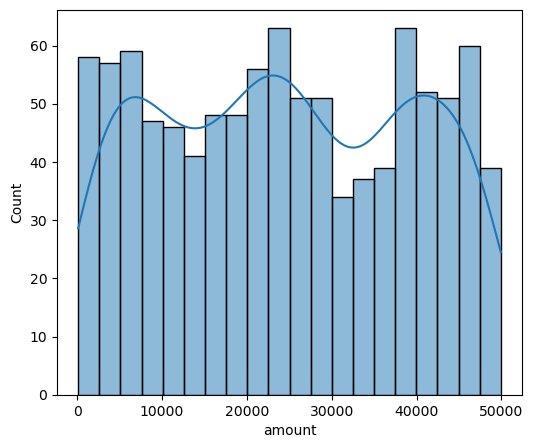

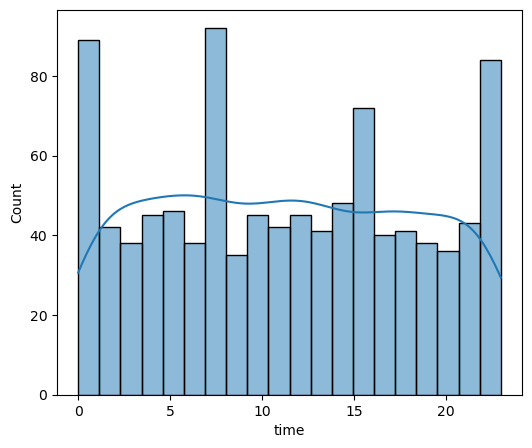

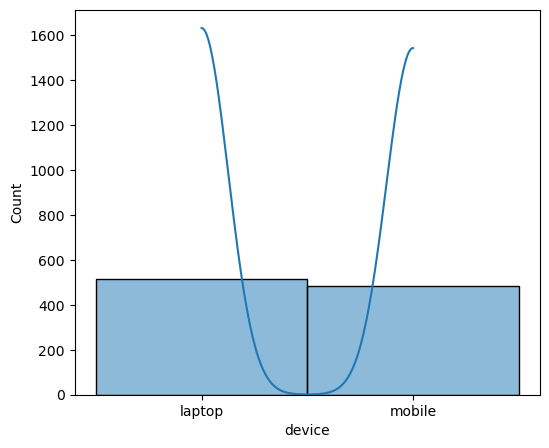

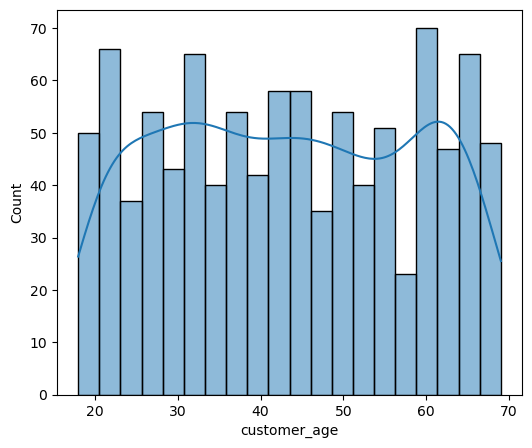

In [10]:
kg = ['amount','time','device','customer_age']
for col in kg:
    plt.figure(figsize=(6,5))
    sns.histplot(df[col],kde=True,bins=20)
    

<Axes: xlabel='device', ylabel='count'>

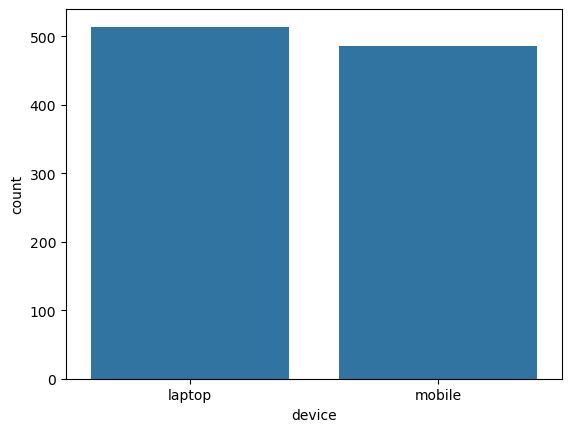

In [11]:
sns.countplot(x=df['device'])

<Axes: xlabel='is_fraud', ylabel='count'>

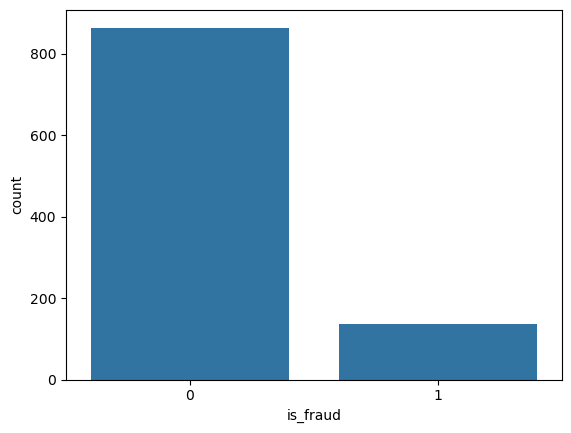

In [12]:
sns.countplot(x=df['is_fraud'])

<Axes: xlabel='transaction_type', ylabel='count'>

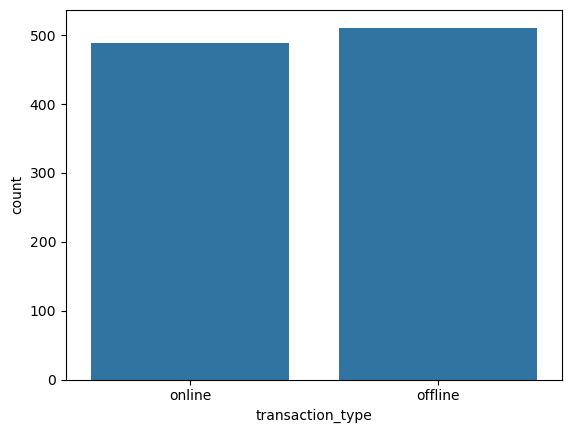

In [13]:
sns.countplot(x=df['transaction_type'])

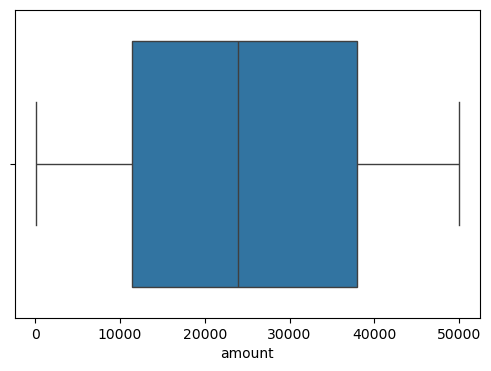

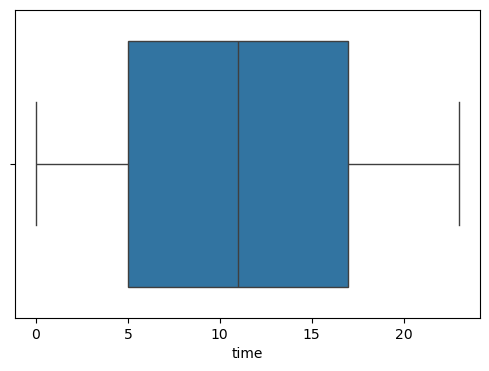

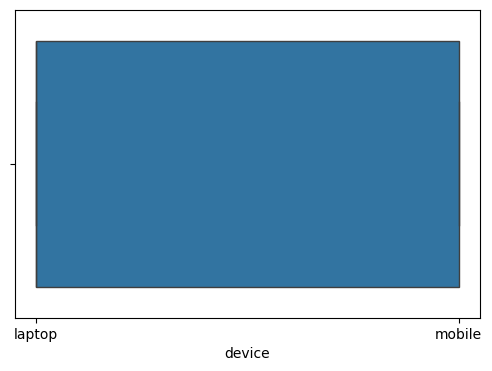

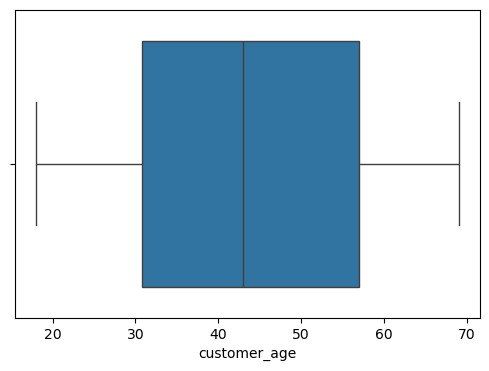

In [14]:
for pig in kg:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[pig])

<Axes: >

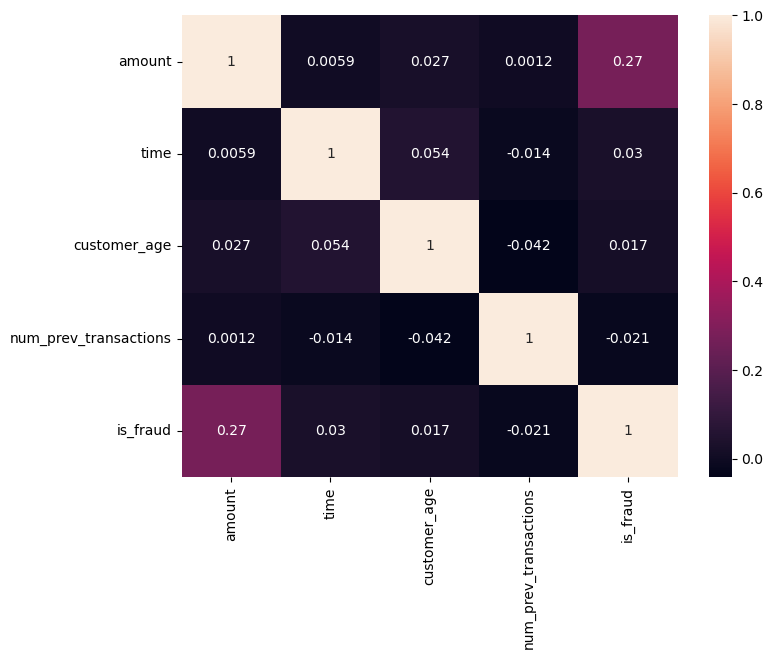

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only =True),annot = True)

In [16]:
good = df.copy()

In [17]:
good.drop_duplicates(inplace=True)

In [18]:
good.shape

(1000, 10)

In [19]:
good

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,online,laptop,india,flipkart,credit,62,25,0
1,960,5,online,mobile,india,amazon,debit,23,45,0
2,38258,19,offline,laptop,foreign,walmart,debit,52,13,0
3,44832,1,online,laptop,india,amazon,debit,63,44,0
4,11384,23,offline,mobile,foreign,amazon,debit,31,43,0
...,...,...,...,...,...,...,...,...,...,...
995,15828,13,offline,mobile,foreign,amazon,debit,64,25,0
996,23375,3,online,laptop,india,flipkart,credit,28,24,0
997,6838,12,offline,laptop,foreign,walmart,debit,36,10,0
998,16013,7,online,mobile,foreign,local_shop,credit,52,22,0


In [20]:
good.value_counts()

amount  time  transaction_type  device  location  merchant    card_type  customer_age  num_prev_transactions  is_fraud
109     1     online            mobile  india     walmart     credit     56            15                     0           1
33407   22    offline           laptop  india     local_shop  credit     69            1                      0           1
32452   21    online            laptop  india     local_shop  credit     38            4                      0           1
32579   2     online            laptop  india     local_shop  debit      36            5                      0           1
32582   18    offline           laptop  foreign   amazon      credit     27            33                     0           1
                                                                                                                         ..
17064   2     online            laptop  india     local_shop  debit      35            41                     0           1
17119   12   

In [21]:
good['merchant'].unique()

array(['flipkart', 'amazon', 'walmart', 'local_shop'], dtype=object)

In [22]:
from sklearn.preprocessing import LabelEncoder

merchant_encoder = LabelEncoder()
location_encoder = LabelEncoder()
device_encoder = LabelEncoder()
transaction_encoder = LabelEncoder()
card_encoder = LabelEncoder()

good['merchant'] = merchant_encoder.fit_transform(good['merchant'])
good['location'] = location_encoder.fit_transform(good['location'])
good['device'] = device_encoder.fit_transform(good['device'])
good['transaction_type'] = transaction_encoder.fit_transform(good['transaction_type'])
good['card_type'] = card_encoder.fit_transform(good['card_type'])

In [23]:
good

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,1,0,1,1,0,62,25,0
1,960,5,1,1,1,0,1,23,45,0
2,38258,19,0,0,0,3,1,52,13,0
3,44832,1,1,0,1,0,1,63,44,0
4,11384,23,0,1,0,0,1,31,43,0
...,...,...,...,...,...,...,...,...,...,...
995,15828,13,0,1,0,0,1,64,25,0
996,23375,3,1,0,1,1,0,28,24,0
997,6838,12,0,0,0,3,1,36,10,0
998,16013,7,1,1,0,2,0,52,22,0


In [47]:
gp = good[good['customer_age'] < 50]
gp

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
1,960,5,1,1,1,0,1,23,45,0
4,11384,23,0,1,0,0,1,31,43,0
6,16950,5,0,0,1,2,0,25,40,0
7,37294,4,0,0,1,0,1,32,0,0
8,22062,0,1,1,1,0,1,44,42,0
...,...,...,...,...,...,...,...,...,...,...
987,16716,11,1,1,0,0,0,27,47,0
991,14469,12,0,0,0,1,1,29,45,0
993,8043,18,1,1,0,0,0,30,31,0
996,23375,3,1,0,1,1,0,28,24,0


In [25]:
gp = good[(good['customer_age'] <= 50) & (good['amount'] < 50000)]

In [45]:
pg = good[good["amount"] < 51000]
pg

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,1,0,1,1,0,62,25,0
1,960,5,1,1,1,0,1,23,45,0
2,38258,19,0,0,0,3,1,52,13,0
3,44832,1,1,0,1,0,1,63,44,0
4,11384,23,0,1,0,0,1,31,43,0
...,...,...,...,...,...,...,...,...,...,...
995,15828,13,0,1,0,0,1,64,25,0
996,23375,3,1,0,1,1,0,28,24,0
997,6838,12,0,0,0,3,1,36,10,0
998,16013,7,1,1,0,2,0,52,22,0


In [27]:
good.corr()

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
amount,1.000000,0.005892,-0.044164,0.036992,0.009195,0.040003,0.001275,0.026559,0.001175,0.273459
time,0.005892,1.000000,0.019173,0.009652,-0.038687,0.011545,0.042232,0.054203,-0.014312,0.030465
transaction_type,-0.044164,0.019173,1.000000,0.001385,0.016314,-0.099223,-0.080523,-0.011796,-0.023566,0.405573
device,0.036992,0.009652,0.001385,1.000000,0.014399,0.023598,-0.026633,0.029413,0.027187,0.022787
location,0.009195,-0.038687,0.016314,0.014399,1.000000,0.041408,0.008311,-0.061392,0.069498,-0.402340
merchant,0.040003,0.011545,-0.099223,0.023598,0.041408,1.000000,-0.018971,-0.043266,-0.001905,-0.044207
card_type,0.001275,0.042232,-0.080523,-0.026633,0.008311,-0.018971,1.000000,-0.007517,-0.007521,-0.067136
customer_age,0.026559,0.054203,-0.011796,0.029413,-0.061392,-0.043266,-0.007517,1.000000,-0.041865,0.016982
num_prev_transactions,0.001175,-0.014312,-0.023566,0.027187,0.069498,-0.001905,-0.007521,-0.041865,1.000000,-0.021100
is_fraud,0.273459,0.030465,0.405573,0.022787,-0.402340,-0.044207,-0.067136,0.016982,-0.021100,1.000000


In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['transaction_type','device','location','merchant','card_type']

for col in cols:
    good[col] = le.fit_transform(good[col])

In [29]:
X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

In [30]:
y

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    0
997    0
998    0
999    0
Name: is_fraud, Length: 1000, dtype: int64

In [31]:
X = good.drop("is_fraud", axis=1)
y = good["is_fraud"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\great\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
y_train

29     0
535    0
695    0
557    0
836    0
      ..
106    0
270    0
860    0
435    0
102    0
Name: is_fraud, Length: 800, dtype: int64

In [34]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [35]:
y_pred_proba = model.predict_proba(X_test)
y_pred_proba

array([[9.99028158e-01, 9.71842165e-04],
       [9.44266568e-01, 5.57334318e-02],
       [9.25115713e-01, 7.48842872e-02],
       [9.55752014e-01, 4.42479862e-02],
       [9.99212702e-01, 7.87297786e-04],
       [9.48848156e-01, 5.11518436e-02],
       [9.99741309e-01, 2.58690720e-04],
       [9.98177385e-01, 1.82261509e-03],
       [9.99469433e-01, 5.30566939e-04],
       [9.05558495e-01, 9.44415055e-02],
       [7.65302713e-01, 2.34697287e-01],
       [9.99923769e-01, 7.62314815e-05],
       [9.99845848e-01, 1.54151671e-04],
       [9.92635945e-01, 7.36405535e-03],
       [7.30355753e-01, 2.69644247e-01],
       [8.51078250e-01, 1.48921750e-01],
       [9.73690311e-01, 2.63096893e-02],
       [9.99999047e-01, 9.53207128e-07],
       [9.99541565e-01, 4.58434649e-04],
       [1.55620072e-01, 8.44379928e-01],
       [6.83596326e-01, 3.16403674e-01],
       [9.97474666e-01, 2.52533408e-03],
       [9.99804428e-01, 1.95571780e-04],
       [9.11641882e-02, 9.08835812e-01],
       [9.222656

In [36]:
sample_pred = model.predict_proba(X_test[0:1])
print(sample_pred)

[[9.99028158e-01 9.71842165e-04]]


In [37]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [38]:
good

,amount,time,transaction_type,device,location,merchant,card_type,customer_age,num_prev_transactions,is_fraud
0,15895,4,1,0,1,1,0,62,25,0
1,960,5,1,1,1,0,1,23,45,0
2,38258,19,0,0,0,3,1,52,13,0
3,44832,1,1,0,1,0,1,63,44,0
4,11384,23,0,1,0,0,1,31,43,0
...,...,...,...,...,...,...,...,...,...,...
995,15828,13,0,1,0,0,1,64,25,0
996,23375,3,1,0,1,1,0,28,24,0
997,6838,12,0,0,0,3,1,36,10,0
998,16013,7,1,1,0,2,0,52,22,0


In [40]:
fg = [[25000,14,1,0,1,2,1,30,10]]

paglu = model.predict(fg)
paglu

c:\Users\great\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
print(confusion_matrix(y_test, y_pred))

[[172   0]
 [  0  28]]
